# 01 - The vehicle model

**Goal.** Derive, from geometry, the plant that everything else in the course
controls: a vehicle tracking a lane. We build the kinematic bicycle model from the
rolling (no-slip) constraints, rewrite it in road-relative *error coordinates*,
discretise it, linearise it term by term, and check the structural properties
(controllability, observability) that later let a controller and an estimator work.

Why a model at all? The controller (notebook 02) and the Kalman monitor (notebook
05) are both *model-based*: they use a mathematical prediction of how the vehicle
moves. The quality of that model sets the quality of both. So we take it seriously,
and we quantify where it stops being valid.

## 1. The kinematic bicycle model

At low lateral acceleration the two wheels on each axle can be lumped into one,
giving a **bicycle**: one rear wheel, one steered front wheel, wheelbase $L$. We
place the reference point at the **rear axle** and take the state $(X, Y, \psi)$ =
position and heading in the ground frame.

The key modelling assumption is **no side-slip**: each wheel rolls in the direction
it points (a nonholonomic constraint [4]). Then

- the rear wheel moves along the heading, so $\dot X = v\cos\psi,\; \dot Y = v\sin\psi$;
- the front wheel points at $\psi+\delta$; requiring both wheels to share one
  instantaneous centre of rotation (ICR) fixes the turn radius $R=L/\tan\delta$,
  hence the yaw rate

$$ \dot\psi = \frac{v}{R} = \frac{v}{L}\tan\delta. $$

Collecting these,

$$ \dot X = v\cos\psi,\qquad \dot Y = v\sin\psi,\qquad \dot\psi=\frac{v}{L}\tan\delta. \tag{1} $$

This is the standard kinematic bicycle [1,2]. The schematic below shows the
geometry; note the ICR sits on the line through the rear axle, perpendicular to the
vehicle heading, at distance $R$.

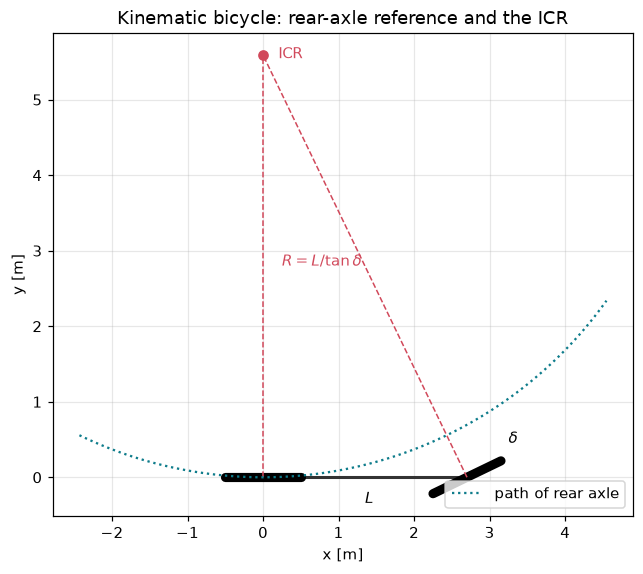

For delta = 0.45 rad, turning radius R = 5.59 m


In [1]:
import numpy as np, matplotlib.pyplot as plt

L, delta = 2.7, 0.45
R = L/np.tan(delta)
fig, ax = plt.subplots(figsize=(6, 5.2))
ax.plot([0, L], [0, 0], color="#333", lw=2, zorder=2)              # chassis rear->front
ax.plot([-0.5, 0.5], [0, 0], color="k", lw=6, solid_capstyle="round")   # rear wheel (heading)
Rm = np.array([[np.cos(delta), -np.sin(delta)], [np.sin(delta), np.cos(delta)]])
fw = Rm @ np.array([[-0.5, 0.5], [0, 0]])
ax.plot(L + fw[0], fw[1], color="k", lw=6, solid_capstyle="round")      # steered front wheel
ax.plot(0, R, 'o', color="#d1495b", zorder=3)
ax.annotate("ICR", (0, R), textcoords="offset points", xytext=(10, -2), color="#d1495b")
ax.plot([0, 0], [0, R], '--', color="#d1495b", lw=1)
ax.plot([L, 0], [0, R], '--', color="#d1495b", lw=1)
th = np.linspace(-0.45, 0.95, 120)
ax.plot(R*np.sin(th), R - R*np.cos(th), ':', color="#0e7c8b", label="path of rear axle")
ax.annotate("$L$", (L/2, -0.35))
ax.annotate("$\\delta$", (L + 0.55, 0.45))
ax.annotate("$R = L/\\tan\\delta$", (0.25, R/2), color="#d1495b")
ax.set_aspect("equal"); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title("Kinematic bicycle: rear-axle reference and the ICR")
ax.legend(loc="lower right"); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print("For delta = %.2f rad, turning radius R = %.2f m" % (delta, R))

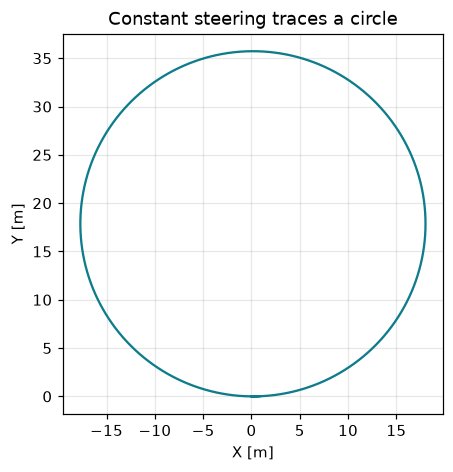

radius from geometry L/tan(delta) = 17.86 m   from simulation = 17.86 m


In [2]:
# Sanity check: a constant steering angle should trace a circle of radius L/tan(delta)
v, L, Ts = 15.0, 2.7, 0.02
def global_step(s, delta):
    X, Y, psi = s
    return np.array([X + v*np.cos(psi)*Ts, Y + v*np.sin(psi)*Ts, psi + v/L*np.tan(delta)*Ts])

delta = 0.15; s = np.array([0.0, 0.0, 0.0]); H = [s]
for _ in range(int(2*np.pi*(L/np.tan(delta))/(v*Ts)) + 3):
    s = global_step(s, delta); H.append(s)
H = np.array(H)
R_true = L/np.tan(delta); R_est = (H[:,0].max() - H[:,0].min())/2

plt.figure(figsize=(4.4, 4.4)); plt.plot(H[:,0], H[:,1], color="#0e7c8b")
plt.gca().set_aspect("equal"); plt.title("Constant steering traces a circle")
plt.xlabel("X [m]"); plt.ylabel("Y [m]"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("radius from geometry L/tan(delta) = %.2f m   from simulation = %.2f m" % (R_true, R_est))

## 2. Road-relative (Frenet) error coordinates

For lane keeping we do not care about absolute position, only the error relative to
the lane centreline. Attach a **Frenet frame** to the reference path, parameterised
by arc length $s$ with curvature $\kappa(s)=\mathrm d\psi_{ref}/\mathrm d s$, and
define

$$ e_y = \text{signed lateral offset from the centreline},\qquad
   e_\psi = \psi - \psi_{ref}. $$

Differentiating the geometric relations gives the exact error dynamics [1,8]

$$ \dot s = \frac{v\cos e_\psi}{1-\kappa\,e_y},\qquad
   \dot e_y = v\sin e_\psi,\qquad
   \dot e_\psi = \frac{v}{L}\tan\delta - \kappa\,\dot s . $$

For small offset ($\kappa e_y \ll 1$) the along-path speed is $\dot s\approx v$, and
the model used throughout the course follows:

$$ \boxed{\;\dot e_y = v\sin e_\psi,\qquad \dot e_\psi = \frac{v}{L}\tan\delta - v\,\kappa\;} \tag{2} $$

So $\kappa$ enters as a **measured disturbance**: on a curve the lane tangent itself
rotates at rate $v\kappa$, and the steering must supply that yaw rate merely to stay
parallel to the lane (this is exactly the feed-forward of notebook 02).

## 3. Discretisation and its error

We integrate (2) in discrete time with **forward Euler** at sample time $T_s$:

$$ x_{k+1} = x_k + T_s\,f(x_k, \delta_k, \kappa_k), \qquad x=[e_y, e_\psi]^\top. $$

Euler has **local truncation error** $O(T_s^2)$ per step and therefore **global
error** $O(T_s)$ over a fixed horizon - it is a first-order method [7]. That is
adequate here because $T_s=0.05$ s is small relative to the vehicle time constants,
but it is worth *seeing* the order rather than asserting it: below we compare Euler
against a high-accuracy RK4 reference and recover the slope-1 line on a log-log
plot.

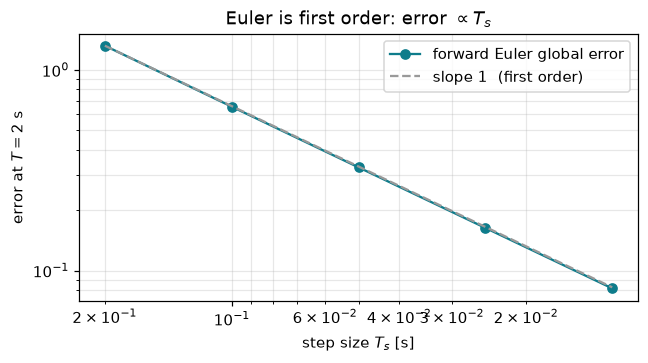

fitted convergence order = 1.00  (theory: 1)


In [3]:
v, L, Ts = 15.0, 2.7, 0.05
delta, kappa = 0.1, 0.0
x0 = np.array([0.2, 0.05])
def f(x): return np.array([v*np.sin(x[1]), v/L*np.tan(delta) - v*kappa])
def euler(x, h): return x + h*f(x)
def rk4(x, h):
    k1 = f(x); k2 = f(x + 0.5*h*k1); k3 = f(x + 0.5*h*k2); k4 = f(x + h*k3)
    return x + h/6*(k1 + 2*k2 + 2*k3 + k4)
def integrate(step, h, T=2.0):
    x = x0.copy()
    for _ in range(int(round(T/h))): x = step(x, h)
    return x

ref = integrate(rk4, 1e-4)
hs = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])
err = np.array([np.linalg.norm(integrate(euler, h) - ref) for h in hs])

plt.figure(figsize=(6, 3.4))
plt.loglog(hs, err, 'o-', color="#0e7c8b", label="forward Euler global error")
plt.loglog(hs, err[0]*(hs/hs[0]), '--', color="#999", label="slope 1  (first order)")
plt.gca().invert_xaxis()
plt.xlabel("step size $T_s$ [s]"); plt.ylabel("error at $T=2$ s")
plt.title("Euler is first order: error $\\propto T_s$"); plt.legend(); plt.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()
slope = np.polyfit(np.log(hs), np.log(err), 1)[0]
print("fitted convergence order = %.2f  (theory: 1)" % slope)

## 4. Linearisation for design

Controllers and observers are easiest to design on a *linear* model. Linearise (2)
about the centred, aligned operating point $x=0,\ \delta=0$ by taking the Jacobians
of the one-step map $x_{k+1}=F(x_k,\delta_k,\kappa_k)$:

$$ A=\left.\frac{\partial F}{\partial x}\right|_0,\quad
   B=\left.\frac{\partial F}{\partial \delta}\right|_0,\quad
   E=\left.\frac{\partial F}{\partial \kappa}\right|_0 . $$

Term by term, using $\left.\cos e_\psi\right|_0=1$ and $\left.\sec^2\delta\right|_0=1$,

$$ \frac{\partial F_1}{\partial e_y}=1,\;\;
   \frac{\partial F_1}{\partial e_\psi}=vT_s,\;\;
   \frac{\partial F_2}{\partial e_\psi}=1,\;\;
   \frac{\partial F_2}{\partial \delta}=\frac{vT_s}{L},\;\;
   \frac{\partial F_2}{\partial \kappa}=-vT_s, $$

so

$$ A=\begin{bmatrix}1 & vT_s\\ 0 & 1\end{bmatrix},\qquad
   B=\begin{bmatrix}0\\ vT_s/L\end{bmatrix},\qquad
   E=\begin{bmatrix}0\\ -vT_s\end{bmatrix}. \tag{3} $$

The approximation error comes from $\sin e_\psi\approx e_\psi$ and
$\tan\delta\approx\delta$, whose leading terms are *cubic*, so the linear model is
excellent for small errors and degrades smoothly as they grow. Let us see exactly
where.

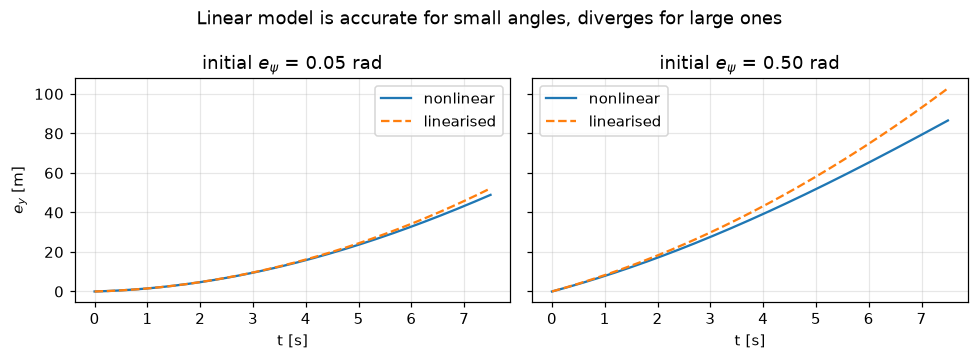

In [4]:
v, L, Ts = 15.0, 2.7, 0.05
A = np.array([[1, v*Ts], [0, 1.]]); Bv = np.array([0, v*Ts/L]); Ev = np.array([0, -v*Ts])
def f_nl(x, d, kap): return np.array([x[0] + v*np.sin(x[1])*Ts, x[1] + (v/L*np.tan(d) - v*kap)*Ts])
def f_lin(x, d, kap): return A@x + Bv*d + Ev*kap

t = np.arange(151)*Ts
fig, ax = plt.subplots(1, 2, figsize=(9, 3.3), sharey=True)
for a, e0 in zip(ax, (0.05, 0.5)):
    xn = np.array([0.0, e0]); xl = np.array([0.0, e0]); Hn, Hl = [0.0], [0.0]
    for _ in range(150):
        xn = f_nl(xn, 0.02, 0.0); xl = f_lin(xl, 0.02, 0.0); Hn.append(xn[0]); Hl.append(xl[0])
    a.plot(t, Hn, label="nonlinear"); a.plot(t, Hl, '--', label="linearised")
    a.set_title("initial $e_\\psi$ = %.2f rad" % e0); a.set_xlabel("t [s]"); a.grid(alpha=.3); a.legend()
ax[0].set_ylabel("$e_y$ [m]")
fig.suptitle("Linear model is accurate for small angles, diverges for large ones")
plt.tight_layout(); plt.show()

## 5. Structural properties

Two questions decide whether model-based control and estimation are even possible.

**Open-loop behaviour.** The eigenvalues of $A$ are both $1$: the error dynamics are
a marginally stable *integrator chain* (heading error integrates into lateral
error). Errors do not grow explosively, but they do not decay either - hence the
need for feedback.

**Controllability.** Can steering drive any error to zero? Yes iff $[\,B\ \ AB\,]$ has
full rank (notebook 02 uses this).

**Observability.** In the full system we do not measure the state directly. Can we
reconstruct it from measurements? With the perception giving both components,
$C=I$, this is immediate; more interestingly, even measuring only the lateral
offset ($C=[1,\ 0]$) the pair $(A,C)$ is observable, so heading error can be inferred
over time [5,6]. That is what makes the Kalman monitor of notebook 05 well posed.

In [5]:
A = np.array([[1, v*Ts], [0, 1.]]); B = np.array([[0.], [v*Ts/L]])
ctrb = np.hstack([B, A@B])
C = np.array([[1.0, 0.0]])                     # measure only lateral offset
obsv = np.vstack([C, C@A])
print("eigenvalues of A            :", np.linalg.eigvals(A), " (integrator chain)")
print("rank[ B  AB ]  (controllab.):", np.linalg.matrix_rank(ctrb), " / 2")
print("rank[ C; CA ]  (observab.)  :", np.linalg.matrix_rank(obsv), " / 2  from e_y alone")

eigenvalues of A            : [1.+0.j 1.+0.j]  (integrator chain)
rank[ B  AB ]  (controllab.): 2  / 2
rank[ C; CA ]  (observab.)  : 2  / 2  from e_y alone


## 6. When does this model stop being valid?

The kinematic model assumes tyres do not slip, which holds only at modest lateral
acceleration. On a curve of radius $R$ the lateral acceleration is

$$ a_y = \frac{v^2}{R} = v^2\,\kappa . $$

A common rule of thumb is that the kinematic model is trustworthy while
$a_y \lesssim 0.5\,\mu g$ (roughly half of the tyre-road friction limit); beyond
that, side-slip matters and one should switch to a **dynamic bicycle model** with
tyre forces [1,2,3]. Kong et al. [2] compare the two for control design, and Polack
et al. [3] give consistency conditions for using the kinematic model in planning.

For this course we stay well inside the valid region: at $v=15$ m/s the largest
curvature we test, $|\kappa|=0.04$, gives $a_y = 9\ \mathrm{m/s^2}\approx 0.9g$ -
deliberately near the edge, which is part of why that scenario is "out of
distribution" for the perception *and* stressful for the plant.

In [6]:
v = 15.0
for kappa in (0.012, 0.022, 0.04):
    print("kappa = %.3f 1/m  ->  R = %5.1f m,  a_y = %.2f m/s^2  = %.2f g"
          % (kappa, 1/kappa, v**2*kappa, v**2*kappa/9.81))

kappa = 0.012 1/m  ->  R =  83.3 m,  a_y = 2.70 m/s^2  = 0.28 g
kappa = 0.022 1/m  ->  R =  45.5 m,  a_y = 4.95 m/s^2  = 0.50 g
kappa = 0.040 1/m  ->  R =  25.0 m,  a_y = 9.00 m/s^2  = 0.92 g


### Exercises

1. Re-derive $\dot\psi=(v/L)\tan\delta$ from the ICR geometry (hint: the front and
   rear wheels share one centre of rotation; write the radius to each).
2. In the discretisation study, replace Euler with the midpoint method and confirm
   the fitted order becomes 2.
3. Drive the *global* model (1) along a sinusoidally curving reference, compute
   $e_y, e_\psi$, and check they match the error model (2) - where do they start to
   differ, and why (look at the $1-\kappa e_y$ term)?
4. Compute the lateral acceleration at which the kinematic assumption breaks for a
   dry road ($\mu\approx 0.9$). Which of the course scenarios approach it?

## References

1. R. Rajamani. *Vehicle Dynamics and Control,* 2nd ed. Springer, 2012. (Kinematic and dynamic models; lane-keeping error dynamics.)
2. J. Kong, M. Pfeiffer, G. Schildbach, F. Borrelli. *Kinematic and Dynamic Vehicle Models for Autonomous Driving Control Design.* IEEE Intelligent Vehicles Symposium, 2015. doi:10.1109/IVS.2015.7225830
3. P. Polack, F. Altche, B. d'Andrea-Novel, A. de La Fortelle. *The Kinematic Bicycle Model: a Consistent Model for Planning Feasible Trajectories for Autonomous Vehicles?* IEEE Intelligent Vehicles Symposium, 2017. doi:10.1109/IVS.2017.7995816
4. S. M. LaValle. *Planning Algorithms.* Cambridge University Press, 2006. (Nonholonomic constraints, the simple-car model.)
5. T. Kailath. *Linear Systems.* Prentice Hall, 1980. (Controllability and observability.)
6. J. P. Hespanha. *Linear Systems Theory,* 2nd ed. Princeton University Press, 2018.
7. U. M. Ascher, L. R. Petzold. *Computer Methods for Ordinary Differential Equations and Differential-Algebraic Equations.* SIAM, 1998. (Order of Euler and Runge-Kutta methods.)
8. M. Werling, J. Ziegler, S. Kammel, S. Thrun. *Optimal Trajectory Generation for Dynamic Street Scenarios in a Frenet Frame.* IEEE ICRA, 2010. doi:10.1109/ROBOT.2010.5509799